# Fitness Landscape Analysis für Top Trumps Balancing

## Analyse der Problem-Landschaft mit Exploratory Landscape Analysis (ELA)

Dieses Notebook untersucht die **Struktur der Fitness-Landschaft** des Top Trumps Balancing Problems.

### Warum Landscape Analysis?

Die Fitness-Landschaft beschreibt, wie sich die Fitness (hier: Win Rate und Trick Changes) im Suchraum verhält:
- **Glatte Landschaft:** Ähnliche Lösungen haben ähnliche Fitness → Gradientenbasierte Suche funktioniert gut
- **Raue Landschaft:** Kleine Änderungen führen zu großen Fitness-Sprüngen → Lokale Suche hat Probleme
- **Multimodale Landschaft:** Viele lokale Optima → Globale Optimierer (wie NSGA-II) sind nötig

### Übersicht der Techniken

| Technik | Was sie misst | Interpretation |
|---------|--------------|----------------|
| **ELA Distribution** | Verteilung der Fitness-Werte | Wie sieht die Fitness-Verteilung aus? |
| **ELA Meta** | Fit eines linearen/quadratischen Modells | Ist die Landschaft glatt? |
| **Fitness-Distance Correlation (FDC)** | Korrelation Fitness ↔ Distanz zum Optimum | Führt der Gradient zum Ziel? |
| **Ruggedness** | Häufigkeit von Richtungswechseln | Wie zerklüftet ist die Landschaft? |
| **Information Content** | Entropie der Fitness-Sequenzen | Wie vorhersagbar ist die Fitness? |
| **Dispersion** | Streuung guter Lösungen | Sind Optima verteilt oder geclustert? |

---

## 1. Setup & Abhängigkeiten

In [1]:
# Pflacco ist die Python-Bibliothek für Exploratory Landscape Analysis
%pip install pflacco numpy pandas matplotlib seaborn scipy tqdm --quiet

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 353, in <module>
          main()
        File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 112, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "/Library/Frameworks/Python.framework/Ver

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))
import json
import random
from tqdm import tqdm
from scipy import stats
from scipy.spatial.distance import pdist, squareform

# Pflacco für ELA
try:
    from pflacco.sampling import create_initial_sample
    from pflacco.classical_ela_features import (
        calculate_ela_distribution,
        calculate_ela_meta,
        calculate_dispersion,
        calculate_information_content,
        calculate_nbc
    )
    PFLACCO_AVAILABLE = True
    print("✓ pflacco erfolgreich geladen")
except ImportError:
    PFLACCO_AVAILABLE = False
    print("⚠ pflacco nicht verfügbar - manuelle ELA-Implementierung wird verwendet")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

⚠ pflacco nicht verfügbar - manuelle ELA-Implementierung wird verwendet


In [3]:
# Simulation laden
from simulation import TopTrumpsSimulation, evaluate_deck_detailed

# Reproduzierbarkeit
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Verzeichnisse
RESULTS_DIR = Path('../results')
PLOTS_DIR = Path('../plots')
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

print(f"Seed: {SEED}")

Seed: 42


In [4]:
# Problem-Konfiguration
K = 22  # Karten
L = 4   # Kategorien
N_VAR = K * L  # 88 Dimensionen
XL = 1.0  # Untere Grenze
XU = 10.0  # Obere Grenze

# Simulation erstellen
sim = TopTrumpsSimulation(num_cards=K, num_categories=L)

print(f"Problem-Dimensionalität: {N_VAR}")
print(f"Suchraum: [{XL}, {XU}]^{N_VAR}")
print(f"Suchraum-Volumen: {(XU - XL) ** N_VAR:.2e}")

Problem-Dimensionalität: 88
Suchraum: [1.0, 10.0]^88
Suchraum-Volumen: 9.40e+83


---

## 2. Stichprobe erstellen

### Warum Sampling?

Um die Landschaft zu analysieren, benötigen wir eine **repräsentative Stichprobe** von Punkten im Suchraum.

### Latin Hypercube Sampling (LHS)

LHS ist besser als reines Zufalls-Sampling, weil es den Suchraum **gleichmäßiger abdeckt**:

1. Teile jede Dimension in n gleiche Intervalle
2. Wähle aus jedem Intervall genau einen Punkt
3. Permutiere die Zuordnungen zufällig

**Vorteil:** Jede "Scheibe" des Suchraums enthält genau einen Punkt → bessere Abdeckung

In [5]:
def latin_hypercube_sample(n_samples, n_dim, lower, upper, seed=None):
    """
    Latin Hypercube Sampling für gleichmäßige Abdeckung des Suchraums.
    
    Funktionsweise:
    1. Für jede Dimension: Teile [lower, upper] in n_samples Intervalle
    2. Wähle aus jedem Intervall einen zufälligen Punkt
    3. Permutiere die Auswahl zufällig zwischen Dimensionen
    
    Args:
        n_samples: Anzahl der Stichprobenpunkte
        n_dim: Anzahl der Dimensionen
        lower: Untere Grenze (skalar oder Array)
        upper: Obere Grenze (skalar oder Array)
        seed: Random seed für Reproduzierbarkeit
        
    Returns:
        X: Array der Form (n_samples, n_dim)
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Initialisiere Sample-Matrix
    X = np.zeros((n_samples, n_dim))
    
    # Für jede Dimension
    for d in range(n_dim):
        # Erstelle n_samples Intervalle
        intervals = np.linspace(0, 1, n_samples + 1)
        
        # Wähle zufälligen Punkt in jedem Intervall
        points = np.random.uniform(intervals[:-1], intervals[1:])
        
        # Permutiere die Punkte zufällig
        np.random.shuffle(points)
        
        # Skaliere auf [lower, upper]
        X[:, d] = lower + points * (upper - lower)
    
    return X

print("LHS-Funktion definiert")

LHS-Funktion definiert


In [6]:
# Stichprobengröße
# Faustregel: min. 50 * n_dim für zuverlässige ELA-Features
# Aber: Jede Evaluation ist teuer (R Simulationen)!
# Kompromiss: 300-500 Samples mit R=50 (schnell) für Landscape Analysis

N_SAMPLES = 500  # Number of sample points
R_FAST = 50      # Simulations per evaluation (fast for landscape analysis)

print(f"Sample size: {N_SAMPLES}")
print(f"Simulations per point: {R_FAST}")
print(f"Total simulations: {N_SAMPLES * R_FAST:,}")
print(f"Samples/Dimensions ratio: {N_SAMPLES / N_VAR:.1f}x (recommended: > 5x)")

Stichprobengröße: 500
Simulationen pro Punkt: 50
Gesamt-Simulationen: 25,000
Verhältnis Samples/Dimensionen: 5.7x (empfohlen: > 5x)


In [7]:
# LHS Stichprobe erstellen
print("Erstelle Latin Hypercube Sample...")
X_sample = latin_hypercube_sample(N_SAMPLES, N_VAR, XL, XU, seed=SEED)

print(f"Sample-Shape: {X_sample.shape}")
print(f"Wertebereich: [{X_sample.min():.2f}, {X_sample.max():.2f}]")

Erstelle Latin Hypercube Sample...
Sample-Shape: (500, 88)
Wertebereich: [1.00, 10.00]


In [8]:
# Fitness evaluieren
print(f"Evaluiere {N_SAMPLES} Decks mit je R={R_FAST} Simulationen...")

F_fairness = []   # Win Rate (Objective 1)
F_excitement = [] # Trick Changes (Objective 2)

for i, x in enumerate(tqdm(X_sample, desc="Evaluating")):
    result = evaluate_deck_detailed(sim, x, R=R_FAST)
    F_fairness.append(result['win_rate'])
    F_excitement.append(result['trick_changes'])

F_fairness = np.array(F_fairness)
F_excitement = np.array(F_excitement)

print(f"\nFairness (Win Rate):")
print(f"  Range: [{F_fairness.min():.3f}, {F_fairness.max():.3f}]")
print(f"  Mean: {F_fairness.mean():.3f}, Std: {F_fairness.std():.3f}")

print(f"\nExcitement (Trick Changes):")
print(f"  Range: [{F_excitement.min():.3f}, {F_excitement.max():.3f}]")
print(f"  Mean: {F_excitement.mean():.3f}, Std: {F_excitement.std():.3f}")

Evaluiere 500 Decks mit je R=50 Simulationen...


Evaluating: 100%|██████████| 500/500 [00:00<00:00, 701.60it/s]


Fairness (Win Rate):
  Range: [0.340, 0.780]
  Mean: 0.553, Std: 0.074

Excitement (Trick Changes):
  Range: [1.100, 2.720]
  Mean: 1.944, Std: 0.289


---

## 3. ELA Distribution Features

### Was misst ELA Distribution?

Diese Features beschreiben die **Verteilung der Fitness-Werte** in der Stichprobe:

| Feature | Beschreibung | Interpretation |
|---------|--------------|----------------|
| **skewness** | Schiefe der Verteilung | > 0: Viele schlechte, wenige gute Lösungen |
| **kurtosis** | "Spitzigkeit" | Hoch: Viele Lösungen nahe am Mittelwert |
| **number_of_peaks** | Anzahl der Modi | > 1: Multimodale Landschaft |

### Warum ist das wichtig?

- **Unimodale Verteilung:** Ein klares Optimum, einfach zu finden
- **Multimodale Verteilung:** Mehrere "gute Regionen", schwieriger

In [9]:
def calculate_distribution_features(y):
    """
    Berechnet Verteilungs-Features der Fitness-Werte.
    
    Manuelle Implementierung der ELA Distribution Features.
    
    Features:
    - skewness: Maß für Asymmetrie der Verteilung
      - = 0: Symmetrisch
      - > 0: Rechtsschief (langer rechter Schwanz)
      - < 0: Linksschief (langer linker Schwanz)
      
    - kurtosis: Maß für "Schwere" der Verteilungsenden
      - = 3: Normalverteilung
      - > 3: Schwere Enden (mehr Ausreißer)
      - < 3: Leichte Enden (weniger Ausreißer)
      
    - number_of_peaks: Geschätzte Anzahl der Modi (über Histogramm)
    """
    features = {}
    
    # Skewness (Schiefe)
    features['skewness'] = stats.skew(y)
    
    # Kurtosis (Wölbung)
    features['kurtosis'] = stats.kurtosis(y)
    
    # Anzahl der Peaks (über Histogramm-Analyse)
    hist, bin_edges = np.histogram(y, bins='auto')
    # Finde lokale Maxima im Histogramm
    peaks = 0
    for i in range(1, len(hist) - 1):
        if hist[i] > hist[i-1] and hist[i] > hist[i+1]:
            peaks += 1
    features['number_of_peaks'] = max(1, peaks)  # Mindestens 1
    
    # Zusätzliche Features
    features['mean'] = np.mean(y)
    features['std'] = np.std(y)
    features['coef_of_variation'] = np.std(y) / np.mean(y) if np.mean(y) != 0 else 0
    features['range'] = np.max(y) - np.min(y)
    features['iqr'] = np.percentile(y, 75) - np.percentile(y, 25)
    
    return features

print("Distribution Features Funktion definiert")

Distribution Features Funktion definiert


In [10]:
# Berechne Distribution Features für beide Objectives
dist_fairness = calculate_distribution_features(F_fairness)
dist_excitement = calculate_distribution_features(F_excitement)

print("=" * 60)
print("ELA DISTRIBUTION FEATURES")
print("=" * 60)

print("\n--- Fairness (Win Rate) ---")
for k, v in dist_fairness.items():
    print(f"  {k}: {v:.4f}")

print("\n--- Excitement (Trick Changes) ---")
for k, v in dist_excitement.items():
    print(f"  {k}: {v:.4f}")

ELA DISTRIBUTION FEATURES

--- Fairness (Win Rate) ---
  skewness: 0.0790
  kurtosis: -0.1387
  number_of_peaks: 6.0000
  mean: 0.5528
  std: 0.0740
  coef_of_variation: 0.1338
  range: 0.4400
  iqr: 0.1000

--- Excitement (Trick Changes) ---
  skewness: 0.1612
  kurtosis: -0.1651
  number_of_peaks: 3.0000
  mean: 1.9442
  std: 0.2891
  coef_of_variation: 0.1487
  range: 1.6200
  iqr: 0.3800


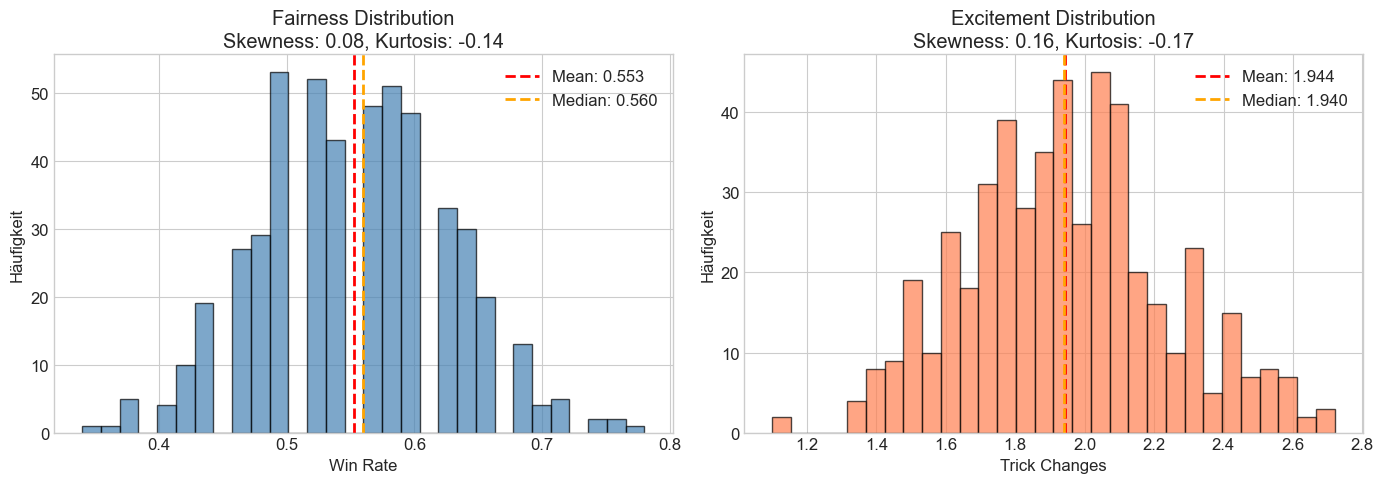


Interpretation:
- Fairness Skewness (0.08): Etwa symmetrisch


In [11]:
# Visualisierung der Verteilungen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fairness Distribution
ax1 = axes[0]
ax1.hist(F_fairness, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(F_fairness.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {F_fairness.mean():.3f}')
ax1.axvline(np.median(F_fairness), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(F_fairness):.3f}')
ax1.set_xlabel('Win Rate')
ax1.set_ylabel('Häufigkeit')
ax1.set_title(f'Fairness Distribution\nSkewness: {dist_fairness["skewness"]:.2f}, Kurtosis: {dist_fairness["kurtosis"]:.2f}')
ax1.legend()

# Excitement Distribution
ax2 = axes[1]
ax2.hist(F_excitement, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(F_excitement.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {F_excitement.mean():.3f}')
ax2.axvline(np.median(F_excitement), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(F_excitement):.3f}')
ax2.set_xlabel('Trick Changes')
ax2.set_ylabel('Häufigkeit')
ax2.set_title(f'Excitement Distribution\nSkewness: {dist_excitement["skewness"]:.2f}, Kurtosis: {dist_excitement["kurtosis"]:.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'landscape_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print(f"- Fairness Skewness ({dist_fairness['skewness']:.2f}): ", end="")
if dist_fairness['skewness'] > 0.5:
    print("Rechtsschief → Wenige sehr gute Lösungen")
elif dist_fairness['skewness'] < -0.5:
    print("Linksschief → Wenige sehr schlechte Lösungen")
else:
    print("Etwa symmetrisch")

---

## 4. Fitness-Distance Correlation (FDC)

### Was ist FDC?

Die **Fitness-Distance Correlation** misst, ob es einen Zusammenhang zwischen der Fitness eines Punktes und seiner Entfernung zum globalen Optimum gibt.

$$\text{FDC} = \text{corr}(f(x), d(x, x^*))$$

wobei:
- $f(x)$ = Fitness des Punktes $x$
- $d(x, x^*)$ = Euklidische Distanz zum besten bekannten Punkt $x^*$

### Interpretation

| FDC-Wert | Interpretation | Schwierigkeit |
|----------|---------------|---------------|
| **< -0.15** | Bessere Lösungen sind näher am Optimum | **Einfach** |
| **-0.15 bis 0.15** | Kein klarer Zusammenhang | **Mittel** |
| **> 0.15** | Bessere Lösungen sind WEITER vom Optimum | **Schwer** (täuschend) |

### Warum ist FDC wichtig?

- **Negative FDC:** Der "Gradient" zeigt grob in Richtung Optimum → lokale Suche funktioniert
- **Positive FDC:** Die Landschaft ist **deceptive** (täuschend) → lokale Suche wird fehlgeleitet
- **Nahe 0:** Fitness und Position sind unabhängig → random search

In [12]:
def fitness_distance_correlation(X, y, minimize=False):
    """
    Berechnet die Fitness-Distance Correlation (FDC).
    
    Die FDC ist ein Maß dafür, wie gut lokale Suche funktioniert:
    - Finde den besten Punkt in der Stichprobe
    - Berechne für jeden anderen Punkt die Distanz zum Besten
    - Korreliere Distanz mit Fitness
    
    Args:
        X: Stichprobenpunkte (n_samples, n_dim)
        y: Fitness-Werte (n_samples,)
        minimize: True wenn niedrigere Werte besser sind
        
    Returns:
        fdc: Korrelationskoeffizient
        distances: Distanzen zum besten Punkt
        best_idx: Index des besten Punktes
    """
    # Finde besten Punkt
    if minimize:
        best_idx = np.argmin(y)
    else:
        best_idx = np.argmax(y)
    
    x_best = X[best_idx]
    
    # Berechne Distanzen zum besten Punkt
    distances = np.linalg.norm(X - x_best, axis=1)
    
    # Korrelation berechnen
    # Für Maximierung: Wenn FDC negativ, sind bessere Lösungen näher am Optimum
    fdc = np.corrcoef(y, distances)[0, 1]
    
    return fdc, distances, best_idx

print("FDC-Funktion definiert")

FDC-Funktion definiert


In [13]:
# FDC für Fairness (Win Rate - maximieren)
fdc_fairness, dist_to_best_fairness, best_idx_fairness = fitness_distance_correlation(
    X_sample, F_fairness, minimize=False
)

# FDC für Excitement (Trick Changes - maximieren)
fdc_excitement, dist_to_best_excitement, best_idx_excitement = fitness_distance_correlation(
    X_sample, F_excitement, minimize=False
)

print("=" * 60)
print("FITNESS-DISTANCE CORRELATION (FDC)")
print("=" * 60)

print(f"\nFairness (Win Rate):")
print(f"  FDC = {fdc_fairness:.4f}")
print(f"  Bester Punkt: Index {best_idx_fairness}, Win Rate = {F_fairness[best_idx_fairness]:.3f}")

print(f"\nExcitement (Trick Changes):")
print(f"  FDC = {fdc_excitement:.4f}")
print(f"  Bester Punkt: Index {best_idx_excitement}, Trick Changes = {F_excitement[best_idx_excitement]:.3f}")

print("\n" + "-" * 60)
print("Interpretation:")
print("-" * 60)

def interpret_fdc(fdc, name):
    if fdc < -0.15:
        return f"{name}: EINFACH - Bessere Lösungen sind näher am Optimum"
    elif fdc > 0.15:
        return f"{name}: SCHWER - Landschaft ist täuschend (deceptive)"
    else:
        return f"{name}: MITTEL - Kein klarer Gradient zum Optimum"

print(interpret_fdc(fdc_fairness, "Fairness"))
print(interpret_fdc(fdc_excitement, "Excitement"))

FITNESS-DISTANCE CORRELATION (FDC)

Fairness (Win Rate):
  FDC = -0.0741
  Bester Punkt: Index 437, Win Rate = 0.780

Excitement (Trick Changes):
  FDC = -0.0210
  Bester Punkt: Index 257, Trick Changes = 2.720

------------------------------------------------------------
Interpretation:
------------------------------------------------------------
Fairness: MITTEL - Kein klarer Gradient zum Optimum
Excitement: MITTEL - Kein klarer Gradient zum Optimum


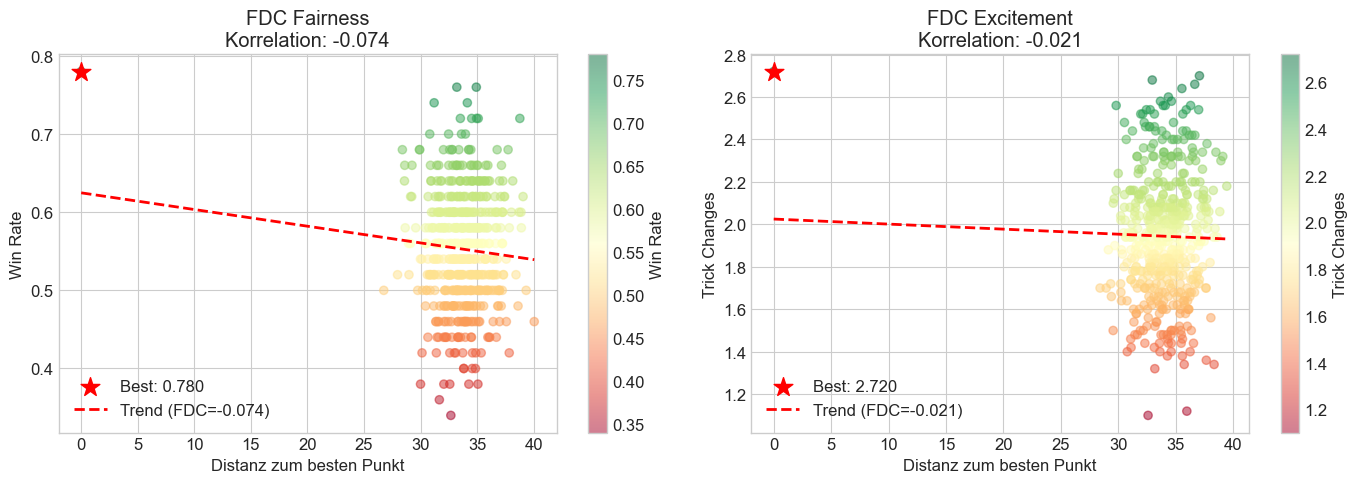

In [14]:
# Visualisierung FDC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fairness FDC
ax1 = axes[0]
scatter1 = ax1.scatter(dist_to_best_fairness, F_fairness, alpha=0.5, c=F_fairness, cmap='RdYlGn')
ax1.scatter(0, F_fairness[best_idx_fairness], color='red', s=200, marker='*', 
            label=f'Best: {F_fairness[best_idx_fairness]:.3f}', zorder=5)

# Trendlinie
z = np.polyfit(dist_to_best_fairness, F_fairness, 1)
p = np.poly1d(z)
x_line = np.linspace(dist_to_best_fairness.min(), dist_to_best_fairness.max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (FDC={fdc_fairness:.3f})')

ax1.set_xlabel('Distanz zum besten Punkt')
ax1.set_ylabel('Win Rate')
ax1.set_title(f'FDC Fairness\nKorrelation: {fdc_fairness:.3f}')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Win Rate')

# Excitement FDC
ax2 = axes[1]
scatter2 = ax2.scatter(dist_to_best_excitement, F_excitement, alpha=0.5, c=F_excitement, cmap='RdYlGn')
ax2.scatter(0, F_excitement[best_idx_excitement], color='red', s=200, marker='*', 
            label=f'Best: {F_excitement[best_idx_excitement]:.3f}', zorder=5)

# Trendlinie
z = np.polyfit(dist_to_best_excitement, F_excitement, 1)
p = np.poly1d(z)
x_line = np.linspace(dist_to_best_excitement.min(), dist_to_best_excitement.max(), 100)
ax2.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (FDC={fdc_excitement:.3f})')

ax2.set_xlabel('Distanz zum besten Punkt')
ax2.set_ylabel('Trick Changes')
ax2.set_title(f'FDC Excitement\nKorrelation: {fdc_excitement:.3f}')
ax2.legend()
plt.colorbar(scatter2, ax=ax2, label='Trick Changes')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'landscape_fdc.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Ruggedness (Rauheit der Landschaft)

### Was ist Ruggedness?

**Ruggedness** misst, wie "zerklüftet" die Fitness-Landschaft ist:
- **Glatte Landschaft:** Benachbarte Lösungen haben ähnliche Fitness
- **Raue Landschaft:** Kleine Änderungen führen zu großen Fitness-Sprüngen

### Messmethode: Random Walks

1. Starte an einem zufälligen Punkt
2. Mache kleine Schritte (Mutationen) zu Nachbarpunkten
3. Zähle, wie oft sich die Fitness-Richtung ändert (auf → ab oder ab → auf)

$$\text{Ruggedness Index} = \frac{\text{Anzahl Richtungswechsel}}{\text{Anzahl Schritte}}$$

### Interpretation

| Index | Landschaft | Konsequenz |
|-------|------------|------------|
| **< 0.3** | Glatt | Gradientensuche funktioniert gut |
| **0.3 - 0.5** | Moderat | Lokale Suche mit Restarts nötig |
| **> 0.5** | Rau | Population-basierte Methoden empfohlen |

In [15]:
def random_walk_ruggedness(sim, start_x, n_steps=100, step_size=0.5, R=30, seed=None):
    """
    Führt einen Random Walk durch und misst die Ruggedness.
    
    Funktionsweise:
    1. Starte bei start_x
    2. Wähle zufällige Richtung, mache Schritt der Größe step_size
    3. Evaluiere Fitness
    4. Wiederhole n_steps mal
    5. Zähle Richtungswechsel in der Fitness-Sequenz
    
    Args:
        sim: TopTrumpsSimulation Instanz
        start_x: Startpunkt (88-dim Vektor)
        n_steps: Anzahl der Schritte
        step_size: Schrittgröße (als Anteil des Suchraums)
        R: Simulationen pro Evaluation
        seed: Random seed
        
    Returns:
        ruggedness_idx: Anteil der Richtungswechsel
        walk_fitness: Fitness-Sequenz entlang des Walks
        walk_positions: Positionen entlang des Walks
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_dim = len(start_x)
    current_x = start_x.copy()
    
    walk_positions = [current_x.copy()]
    walk_fitness_fairness = []
    walk_fitness_excitement = []
    
    # Evaluiere Startpunkt
    result = evaluate_deck_detailed(sim, current_x, R=R)
    walk_fitness_fairness.append(result['win_rate'])
    walk_fitness_excitement.append(result['trick_changes'])
    
    for step in range(n_steps):
        # Zufällige Richtung wählen
        direction = np.random.randn(n_dim)
        direction = direction / np.linalg.norm(direction)  # Normalisieren
        
        # Schritt machen
        new_x = current_x + step_size * direction * (XU - XL)
        
        # Auf Bounds beschränken
        new_x = np.clip(new_x, XL, XU)
        
        # Evaluieren
        result = evaluate_deck_detailed(sim, new_x, R=R)
        walk_fitness_fairness.append(result['win_rate'])
        walk_fitness_excitement.append(result['trick_changes'])
        
        walk_positions.append(new_x.copy())
        current_x = new_x
    
    # Ruggedness berechnen: Zähle Richtungswechsel
    def count_direction_changes(fitness_seq):
        changes = 0
        for i in range(1, len(fitness_seq) - 1):
            d1 = fitness_seq[i] - fitness_seq[i-1]
            d2 = fitness_seq[i+1] - fitness_seq[i]
            if d1 * d2 < 0:  # Richtungswechsel
                changes += 1
        return changes / (len(fitness_seq) - 2) if len(fitness_seq) > 2 else 0
    
    ruggedness_fairness = count_direction_changes(walk_fitness_fairness)
    ruggedness_excitement = count_direction_changes(walk_fitness_excitement)
    
    return {
        'ruggedness_fairness': ruggedness_fairness,
        'ruggedness_excitement': ruggedness_excitement,
        'walk_fairness': np.array(walk_fitness_fairness),
        'walk_excitement': np.array(walk_fitness_excitement),
        'walk_positions': np.array(walk_positions)
    }

print("Random Walk Ruggedness Funktion definiert")

Random Walk Ruggedness Funktion definiert


In [16]:
# Führe mehrere Random Walks durch
N_WALKS = 5
WALK_STEPS = 50
STEP_SIZE = 0.1  # 10% der Suchraum-Breite

print(f"Führe {N_WALKS} Random Walks mit je {WALK_STEPS} Schritten durch...")
print(f"Schrittgröße: {STEP_SIZE * 100}% des Suchraums")
print()

all_walks = []
ruggedness_fairness_values = []
ruggedness_excitement_values = []

for i in tqdm(range(N_WALKS), desc="Random Walks"):
    # Zufälliger Startpunkt
    start = X_sample[np.random.randint(len(X_sample))]
    
    walk_result = random_walk_ruggedness(
        sim, start, 
        n_steps=WALK_STEPS, 
        step_size=STEP_SIZE,
        R=30,
        seed=SEED + i
    )
    
    all_walks.append(walk_result)
    ruggedness_fairness_values.append(walk_result['ruggedness_fairness'])
    ruggedness_excitement_values.append(walk_result['ruggedness_excitement'])

# Durchschnittliche Ruggedness
mean_ruggedness_fairness = np.mean(ruggedness_fairness_values)
mean_ruggedness_excitement = np.mean(ruggedness_excitement_values)

print("\n" + "=" * 60)
print("RUGGEDNESS ANALYSIS")
print("=" * 60)

print(f"\nFairness Ruggedness:")
print(f"  Einzelne Walks: {ruggedness_fairness_values}")
print(f"  Mittelwert: {mean_ruggedness_fairness:.3f}")

print(f"\nExcitement Ruggedness:")
print(f"  Einzelne Walks: {ruggedness_excitement_values}")
print(f"  Mittelwert: {mean_ruggedness_excitement:.3f}")

print("\n" + "-" * 60)
print("Interpretation:")
print("-" * 60)

def interpret_ruggedness(r, name):
    if r < 0.3:
        return f"{name}: GLATT ({r:.2f}) - Gradientensuche funktioniert"
    elif r < 0.5:
        return f"{name}: MODERAT ({r:.2f}) - Lokale Suche mit Restarts"
    else:
        return f"{name}: RAU ({r:.2f}) - Population-basierte Methoden empfohlen"

print(interpret_ruggedness(mean_ruggedness_fairness, "Fairness"))
print(interpret_ruggedness(mean_ruggedness_excitement, "Excitement"))

Führe 5 Random Walks mit je 50 Schritten durch...
Schrittgröße: 10.0% des Suchraums



Random Walks: 100%|██████████| 5/5 [00:00<00:00, 21.18it/s]


RUGGEDNESS ANALYSIS

Fairness Ruggedness:
  Einzelne Walks: [0.7142857142857143, 0.4489795918367347, 0.5102040816326531, 0.5102040816326531, 0.6326530612244898]
  Mittelwert: 0.563

Excitement Ruggedness:
  Einzelne Walks: [0.6938775510204082, 0.7346938775510204, 0.6122448979591837, 0.6122448979591837, 0.7346938775510204]
  Mittelwert: 0.678

------------------------------------------------------------
Interpretation:
------------------------------------------------------------
Fairness: RAU (0.56) - Population-basierte Methoden empfohlen
Excitement: RAU (0.68) - Population-basierte Methoden empfohlen


/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_71596/1947652118.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data, labels=['Fairness', 'Excitement'], patch_artist=True)


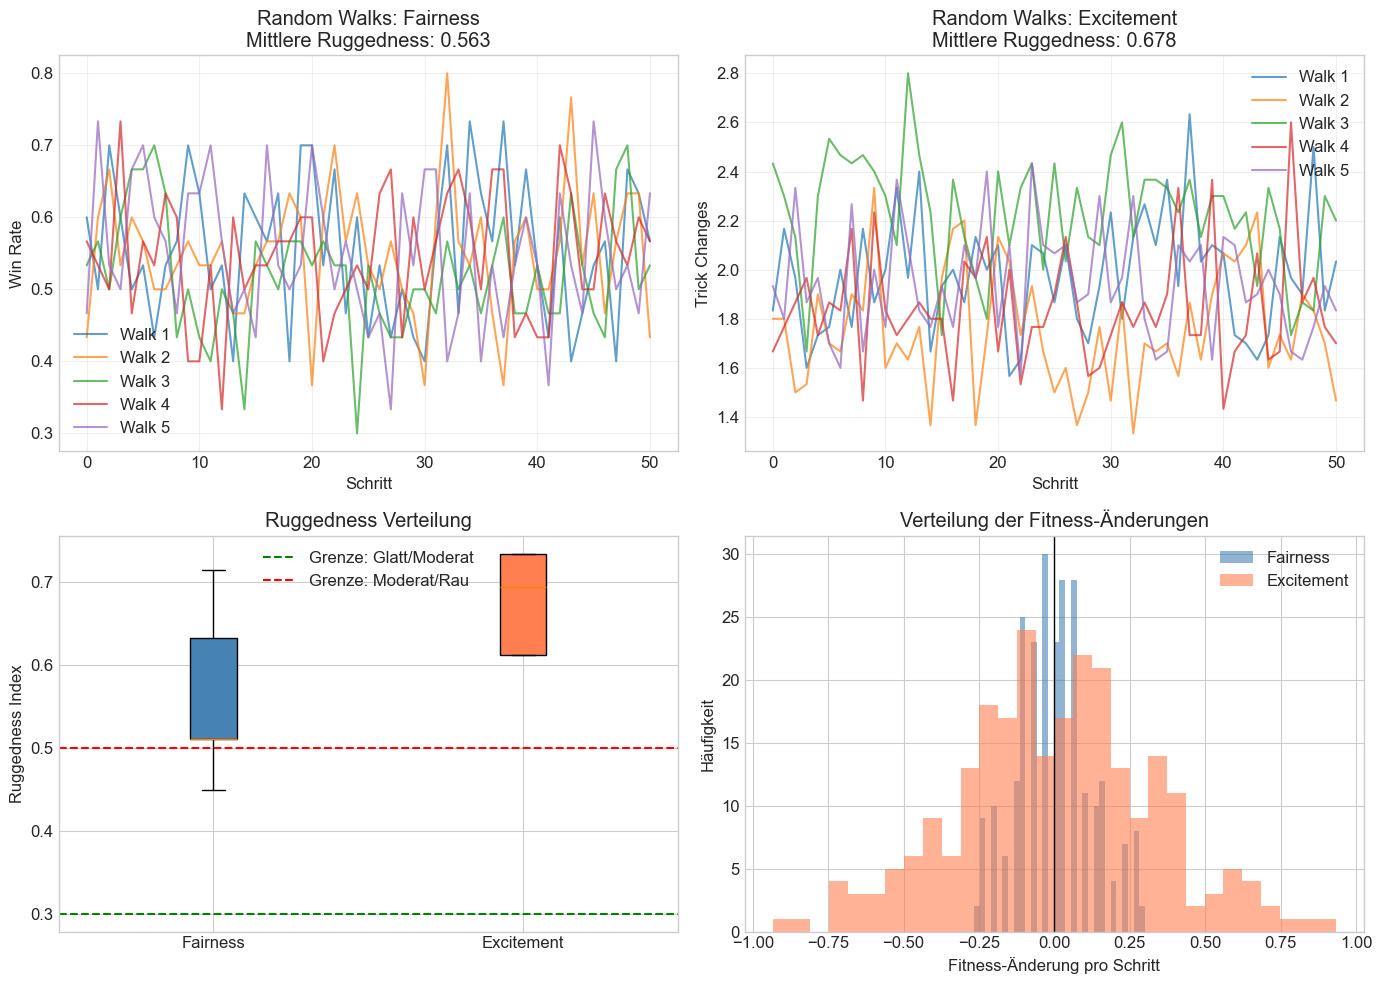

In [17]:
# Visualisierung der Random Walks
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fairness Walks
ax1 = axes[0, 0]
for i, walk in enumerate(all_walks):
    ax1.plot(walk['walk_fairness'], alpha=0.7, label=f'Walk {i+1}')
ax1.set_xlabel('Schritt')
ax1.set_ylabel('Win Rate')
ax1.set_title(f'Random Walks: Fairness\nMittlere Ruggedness: {mean_ruggedness_fairness:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Excitement Walks
ax2 = axes[0, 1]
for i, walk in enumerate(all_walks):
    ax2.plot(walk['walk_excitement'], alpha=0.7, label=f'Walk {i+1}')
ax2.set_xlabel('Schritt')
ax2.set_ylabel('Trick Changes')
ax2.set_title(f'Random Walks: Excitement\nMittlere Ruggedness: {mean_ruggedness_excitement:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Ruggedness Vergleich (Boxplot)
ax3 = axes[1, 0]
data = [ruggedness_fairness_values, ruggedness_excitement_values]
bp = ax3.boxplot(data, labels=['Fairness', 'Excitement'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax3.axhline(0.3, color='green', linestyle='--', label='Grenze: Glatt/Moderat')
ax3.axhline(0.5, color='red', linestyle='--', label='Grenze: Moderat/Rau')
ax3.set_ylabel('Ruggedness Index')
ax3.set_title('Ruggedness Verteilung')
ax3.legend()

# Fitness-Änderungen Histogramm
ax4 = axes[1, 1]
all_changes_fairness = []
all_changes_excitement = []
for walk in all_walks:
    all_changes_fairness.extend(np.diff(walk['walk_fairness']))
    all_changes_excitement.extend(np.diff(walk['walk_excitement']))

ax4.hist(all_changes_fairness, bins=30, alpha=0.6, label='Fairness', color='steelblue')
ax4.hist(all_changes_excitement, bins=30, alpha=0.6, label='Excitement', color='coral')
ax4.axvline(0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Fitness-Änderung pro Schritt')
ax4.set_ylabel('Häufigkeit')
ax4.set_title('Verteilung der Fitness-Änderungen')
ax4.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'landscape_ruggedness.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Dispersion (Streuung guter Lösungen)

### Was misst Dispersion?

**Dispersion** misst, wie weit die besten Lösungen im Suchraum verteilt sind:

1. Wähle die besten p% der Lösungen
2. Berechne den mittleren paarweisen Abstand zwischen ihnen
3. Vergleiche mit dem mittleren Abstand aller Lösungen

$$\text{Dispersion Ratio} = \frac{\text{Mittlerer Abstand der Besten}}{\text{Mittlerer Abstand aller}}$$

### Interpretation

| Ratio | Interpretation | Konsequenz |
|-------|---------------|------------|
| **< 0.5** | Gute Lösungen sind geclustert | Lokale Suche in der Region effektiv |
| **~1.0** | Gute Lösungen sind gleichmäßig verteilt | Globale Suche nötig |
| **> 1.5** | Gute Lösungen sind weiter verteilt als Durchschnitt | Multi-Start-Strategien wichtig |

In [18]:
def calculate_dispersion(X, y, top_percent=10, minimize=False):
    """
    Berechnet die Dispersion der besten Lösungen.
    
    Funktionsweise:
    1. Wähle die besten top_percent% der Lösungen
    2. Berechne den mittleren paarweisen Abstand dieser Lösungen
    3. Vergleiche mit dem mittleren Abstand aller Lösungen
    
    Args:
        X: Stichprobenpunkte (n_samples, n_dim)
        y: Fitness-Werte
        top_percent: Prozentsatz der besten Lösungen
        minimize: True wenn niedrigere Werte besser sind
        
    Returns:
        dispersion_ratio: Verhältnis der Abstände
        mean_dist_best: Mittlerer Abstand der Besten
        mean_dist_all: Mittlerer Abstand aller
    """
    n_top = max(2, int(len(y) * top_percent / 100))
    
    # Finde die besten Lösungen
    if minimize:
        best_indices = np.argsort(y)[:n_top]
    else:
        best_indices = np.argsort(y)[-n_top:]
    
    X_best = X[best_indices]
    
    # Mittlerer paarweiser Abstand der Besten
    dist_best = pdist(X_best)
    mean_dist_best = np.mean(dist_best)
    
    # Mittlerer paarweiser Abstand aller (Stichprobe für Effizienz)
    sample_size = min(500, len(X))
    sample_indices = np.random.choice(len(X), sample_size, replace=False)
    dist_all = pdist(X[sample_indices])
    mean_dist_all = np.mean(dist_all)
    
    dispersion_ratio = mean_dist_best / mean_dist_all if mean_dist_all > 0 else 1.0
    
    return {
        'dispersion_ratio': dispersion_ratio,
        'mean_dist_best': mean_dist_best,
        'mean_dist_all': mean_dist_all,
        'n_top': n_top,
        'best_indices': best_indices
    }

print("Dispersion-Funktion definiert")

Dispersion-Funktion definiert


In [19]:
# Dispersion für verschiedene Top-Prozente berechnen
TOP_PERCENTS = [5, 10, 20]

print("=" * 60)
print("DISPERSION ANALYSIS")
print("=" * 60)

dispersion_results = {'fairness': {}, 'excitement': {}}

for top_p in TOP_PERCENTS:
    disp_fairness = calculate_dispersion(X_sample, F_fairness, top_percent=top_p, minimize=False)
    disp_excitement = calculate_dispersion(X_sample, F_excitement, top_percent=top_p, minimize=False)
    
    dispersion_results['fairness'][top_p] = disp_fairness
    dispersion_results['excitement'][top_p] = disp_excitement
    
    print(f"\nTop {top_p}% Lösungen:")
    print(f"  Fairness: Dispersion Ratio = {disp_fairness['dispersion_ratio']:.3f}")
    print(f"  Excitement: Dispersion Ratio = {disp_excitement['dispersion_ratio']:.3f}")

print("\n" + "-" * 60)
print("Interpretation (Top 10%):")
print("-" * 60)

def interpret_dispersion(ratio, name):
    if ratio < 0.5:
        return f"{name}: GECLUSTERT ({ratio:.2f}) - Gute Lösungen in einer Region"
    elif ratio < 1.2:
        return f"{name}: GLEICHMÄSSIG ({ratio:.2f}) - Gute Lösungen verteilt"
    else:
        return f"{name}: WEIT VERTEILT ({ratio:.2f}) - Multi-Start-Strategien wichtig"

print(interpret_dispersion(dispersion_results['fairness'][10]['dispersion_ratio'], "Fairness"))
print(interpret_dispersion(dispersion_results['excitement'][10]['dispersion_ratio'], "Excitement"))

DISPERSION ANALYSIS

Top 5% Lösungen:
  Fairness: Dispersion Ratio = 0.994
  Excitement: Dispersion Ratio = 0.993

Top 10% Lösungen:
  Fairness: Dispersion Ratio = 0.991
  Excitement: Dispersion Ratio = 1.002

Top 20% Lösungen:
  Fairness: Dispersion Ratio = 0.993
  Excitement: Dispersion Ratio = 0.996

------------------------------------------------------------
Interpretation (Top 10%):
------------------------------------------------------------
Fairness: GLEICHMÄSSIG (0.99) - Gute Lösungen verteilt
Excitement: GLEICHMÄSSIG (1.00) - Gute Lösungen verteilt


---

## 7. Information Content (Entropie)

### Was ist Information Content?

**Information Content** misst, wie "vorhersagbar" die Fitness-Landschaft ist, basierend auf Entropie:

1. Codiere Fitness-Änderungen als Symbole: ▲ (steigend), ▼ (fallend), ─ (gleich)
2. Berechne die Entropie dieser Symbol-Sequenz

$$H = -\sum_s p(s) \log_2 p(s)$$

### Interpretation

| Entropie | Interpretation | Konsequenz |
|----------|---------------|------------|
| **Niedrig (< 0.5)** | Vorhersagbare Muster | Gradient ist konsistent |
| **Mittel (0.5 - 1.0)** | Teilweise vorhersagbar | Lokale Struktur vorhanden |
| **Hoch (> 1.0)** | Zufällig wirkend | Schwierig für lokale Suche |

In [20]:
def calculate_information_content_manual(fitness_sequence, epsilon=0.01):
    """
    Berechnet den Information Content einer Fitness-Sequenz.
    
    Funktionsweise:
    1. Berechne Fitness-Differenzen aufeinanderfolgender Punkte
    2. Klassifiziere jede Differenz: '+' (Anstieg), '-' (Abfall), '0' (neutral)
    3. Berechne Entropie der Symbol-Verteilung
    
    Args:
        fitness_sequence: Array von Fitness-Werten entlang eines Pfades
        epsilon: Schwelle für "keine Änderung"
        
    Returns:
        entropy: Entropie der Symbole
        symbol_counts: Anzahl jedes Symbols
    """
    # Berechne Differenzen
    diffs = np.diff(fitness_sequence)
    
    # Klassifiziere Differenzen
    symbols = []
    for d in diffs:
        if d > epsilon:
            symbols.append('+')
        elif d < -epsilon:
            symbols.append('-')
        else:
            symbols.append('0')
    
    # Zähle Symbole
    symbol_counts = {'+': 0, '-': 0, '0': 0}
    for s in symbols:
        symbol_counts[s] += 1
    
    # Berechne Wahrscheinlichkeiten
    total = len(symbols)
    probs = [count / total for count in symbol_counts.values() if count > 0]
    
    # Berechne Entropie
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)
    
    return {
        'entropy': entropy,
        'symbol_counts': symbol_counts,
        'n_symbols': total,
        'max_entropy': np.log2(3)  # Maximum bei 3 gleichwahrscheinlichen Symbolen
    }

print("Information Content Funktion definiert")

Information Content Funktion definiert


In [21]:
# Information Content aus den Random Walks berechnen
ic_fairness_values = []
ic_excitement_values = []

print("=" * 60)
print("INFORMATION CONTENT ANALYSIS")
print("=" * 60)

for i, walk in enumerate(all_walks):
    ic_f = calculate_information_content_manual(walk['walk_fairness'])
    ic_e = calculate_information_content_manual(walk['walk_excitement'])
    
    ic_fairness_values.append(ic_f['entropy'])
    ic_excitement_values.append(ic_e['entropy'])
    
    print(f"\nWalk {i+1}:")
    print(f"  Fairness: H = {ic_f['entropy']:.3f}, Symbole: {ic_f['symbol_counts']}")
    print(f"  Excitement: H = {ic_e['entropy']:.3f}, Symbole: {ic_e['symbol_counts']}")

mean_ic_fairness = np.mean(ic_fairness_values)
mean_ic_excitement = np.mean(ic_excitement_values)
max_entropy = np.log2(3)

print("\n" + "-" * 60)
print(f"Durchschnittlicher Information Content:")
print(f"  Fairness: {mean_ic_fairness:.3f} (max: {max_entropy:.3f})")
print(f"  Excitement: {mean_ic_excitement:.3f} (max: {max_entropy:.3f})")
print("-" * 60)

def interpret_ic(h, name):
    normalized = h / max_entropy
    if normalized < 0.5:
        return f"{name}: VORHERSAGBAR ({h:.2f}) - Konsistente Muster"
    elif normalized < 0.8:
        return f"{name}: TEILWEISE VORHERSAGBAR ({h:.2f}) - Lokale Struktur"
    else:
        return f"{name}: ZUFÄLLIG ({h:.2f}) - Schwierig für lokale Suche"

print(interpret_ic(mean_ic_fairness, "Fairness"))
print(interpret_ic(mean_ic_excitement, "Excitement"))

INFORMATION CONTENT ANALYSIS

Walk 1:
  Fairness: H = 1.119, Symbole: {'+': 23, '-': 26, '0': 1}
  Excitement: H = 0.999, Symbole: {'+': 26, '-': 24, '0': 0}

Walk 2:
  Fairness: H = 1.408, Symbole: {'+': 23, '-': 21, '0': 6}
  Excitement: H = 1.121, Symbole: {'+': 25, '-': 24, '0': 1}

Walk 3:
  Fairness: H = 1.441, Symbole: {'+': 20, '-': 23, '0': 7}
  Excitement: H = 1.172, Symbole: {'+': 19, '-': 29, '0': 2}

Walk 4:
  Fairness: H = 1.444, Symbole: {'+': 22, '-': 21, '0': 7}
  Excitement: H = 1.252, Symbole: {'+': 27, '-': 20, '0': 3}

Walk 5:
  Fairness: H = 1.197, Symbole: {'+': 22, '-': 26, '0': 2}
  Excitement: H = 0.995, Symbole: {'+': 23, '-': 27, '0': 0}

------------------------------------------------------------
Durchschnittlicher Information Content:
  Fairness: 1.322 (max: 1.585)
  Excitement: 1.108 (max: 1.585)
------------------------------------------------------------
Fairness: ZUFÄLLIG (1.32) - Schwierig für lokale Suche
Excitement: TEILWEISE VORHERSAGBAR (1.11) - 

---

## 8. Zusammenfassung & Gesamt-Interpretation

In [22]:
# Alle Ergebnisse zusammenfassen
landscape_results = {
    'config': {
        'K': K,
        'L': L,
        'n_var': N_VAR,
        'n_samples': N_SAMPLES,
        'R_fast': R_FAST,
        'seed': SEED
    },
    'distribution': {
        'fairness': dist_fairness,
        'excitement': dist_excitement
    },
    'fdc': {
        'fairness': fdc_fairness,
        'excitement': fdc_excitement
    },
    'ruggedness': {
        'fairness_mean': mean_ruggedness_fairness,
        'fairness_values': ruggedness_fairness_values,
        'excitement_mean': mean_ruggedness_excitement,
        'excitement_values': ruggedness_excitement_values
    },
    'dispersion': {
        'fairness_10pct': dispersion_results['fairness'][10]['dispersion_ratio'],
        'excitement_10pct': dispersion_results['excitement'][10]['dispersion_ratio']
    },
    'information_content': {
        'fairness_mean': mean_ic_fairness,
        'excitement_mean': mean_ic_excitement,
        'max_entropy': max_entropy
    }
}

# Speichern
with open(RESULTS_DIR / 'landscape_analysis.json', 'w') as f:
    # Konvertiere numpy-Typen für JSON
    def convert(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (np.float64, np.float32)):
            return float(obj)
        elif isinstance(obj, (np.int64, np.int32)):
            return int(obj)
        elif isinstance(obj, dict):
            return {k: convert(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert(i) for i in obj]
        return obj
    
    json.dump(convert(landscape_results), f, indent=2)

print("Ergebnisse gespeichert in results/landscape_analysis.json")

Ergebnisse gespeichert in results/landscape_analysis.json


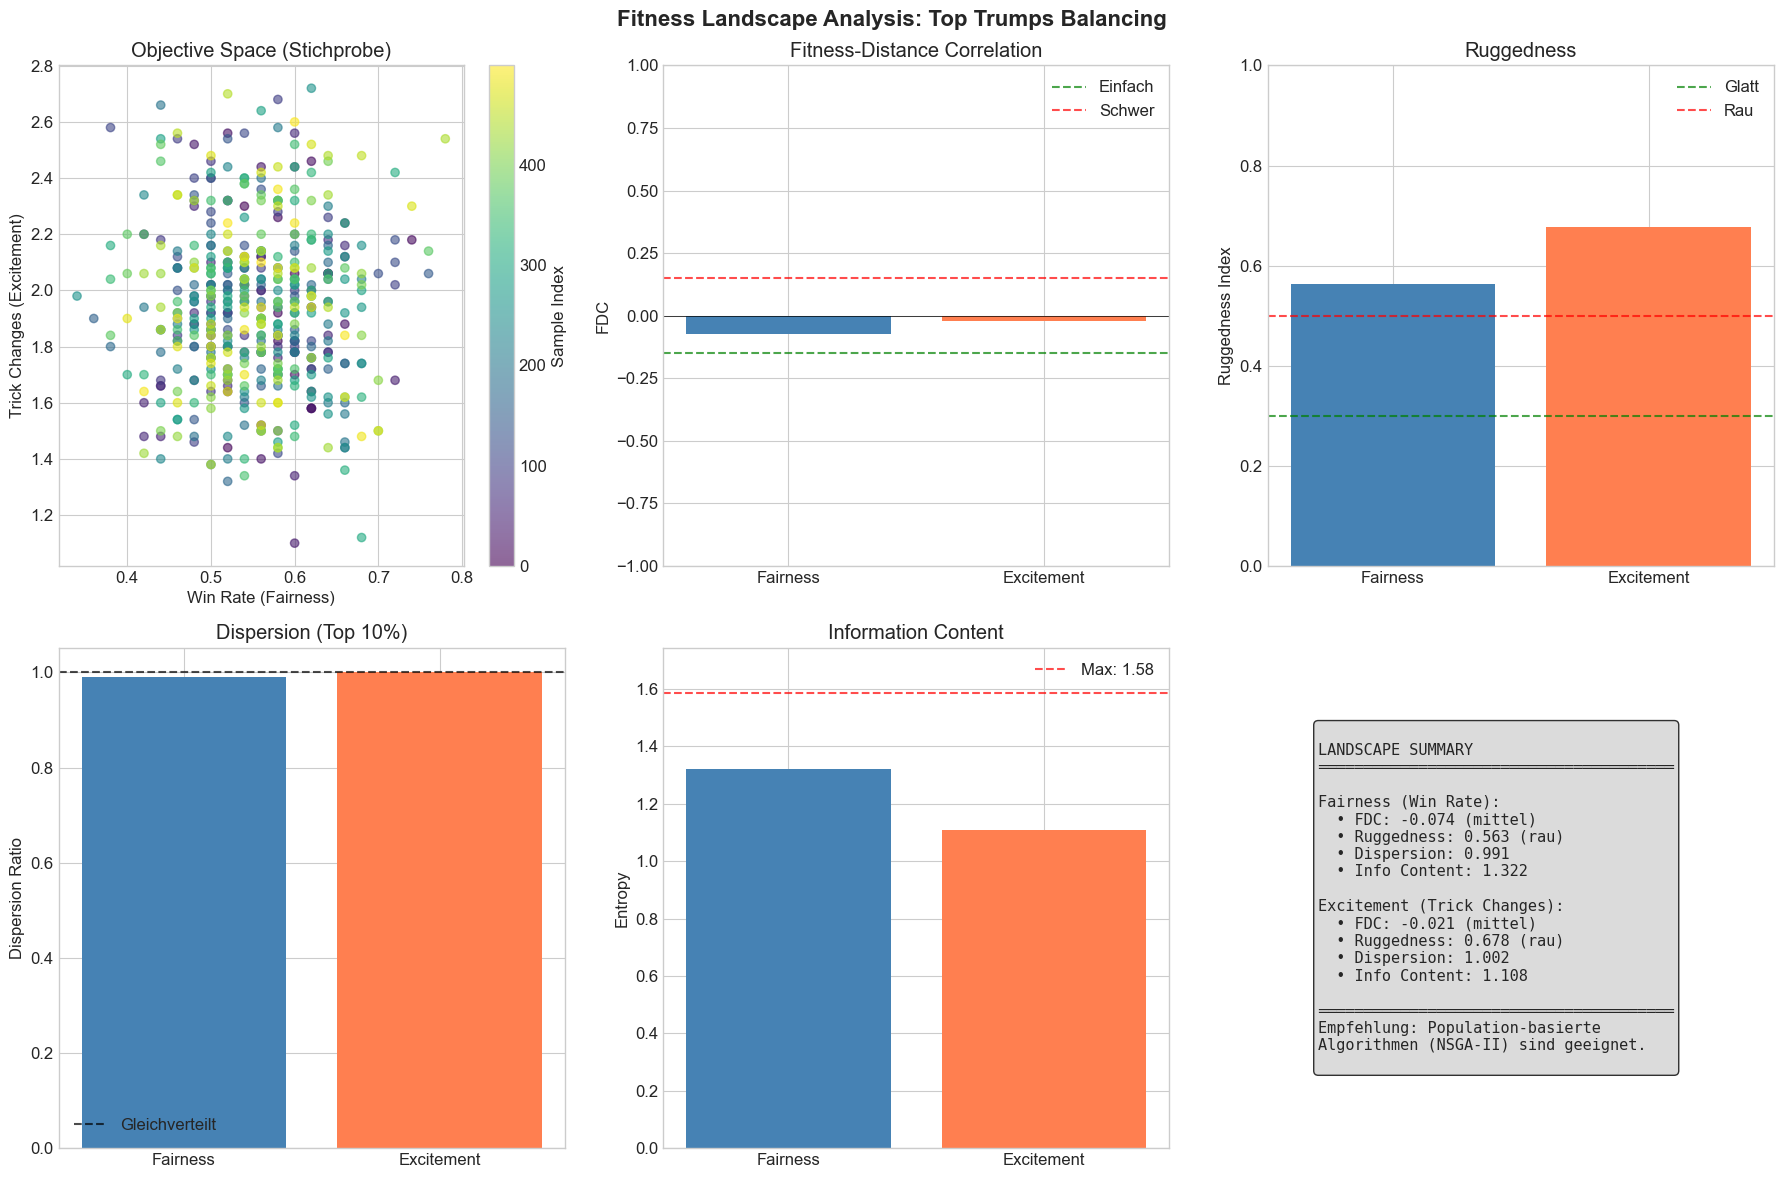

In [23]:
# Gesamt-Visualisierung
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Objective Space
ax1 = axes[0, 0]
scatter = ax1.scatter(F_fairness, F_excitement, alpha=0.6, c=np.arange(len(F_fairness)), cmap='viridis')
ax1.set_xlabel('Win Rate (Fairness)')
ax1.set_ylabel('Trick Changes (Excitement)')
ax1.set_title('Objective Space (Stichprobe)')
plt.colorbar(scatter, ax=ax1, label='Sample Index')

# 2. FDC Vergleich
ax2 = axes[0, 1]
fdc_data = [fdc_fairness, fdc_excitement]
colors = ['steelblue', 'coral']
bars = ax2.bar(['Fairness', 'Excitement'], fdc_data, color=colors)
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(-0.15, color='green', linestyle='--', alpha=0.7, label='Einfach')
ax2.axhline(0.15, color='red', linestyle='--', alpha=0.7, label='Schwer')
ax2.set_ylabel('FDC')
ax2.set_title('Fitness-Distance Correlation')
ax2.legend()
ax2.set_ylim(-1, 1)

# 3. Ruggedness Vergleich
ax3 = axes[0, 2]
rugg_data = [mean_ruggedness_fairness, mean_ruggedness_excitement]
bars = ax3.bar(['Fairness', 'Excitement'], rugg_data, color=colors)
ax3.axhline(0.3, color='green', linestyle='--', alpha=0.7, label='Glatt')
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Rau')
ax3.set_ylabel('Ruggedness Index')
ax3.set_title('Ruggedness')
ax3.legend()
ax3.set_ylim(0, 1)

# 4. Dispersion
ax4 = axes[1, 0]
disp_data = [dispersion_results['fairness'][10]['dispersion_ratio'], 
             dispersion_results['excitement'][10]['dispersion_ratio']]
bars = ax4.bar(['Fairness', 'Excitement'], disp_data, color=colors)
ax4.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Gleichverteilt')
ax4.set_ylabel('Dispersion Ratio')
ax4.set_title('Dispersion (Top 10%)')
ax4.legend()

# 5. Information Content
ax5 = axes[1, 1]
ic_data = [mean_ic_fairness, mean_ic_excitement]
bars = ax5.bar(['Fairness', 'Excitement'], ic_data, color=colors)
ax5.axhline(max_entropy, color='red', linestyle='--', alpha=0.7, label=f'Max: {max_entropy:.2f}')
ax5.set_ylabel('Entropy')
ax5.set_title('Information Content')
ax5.legend()
ax5.set_ylim(0, max_entropy * 1.1)

# 6. Zusammenfassung Tabelle
ax6 = axes[1, 2]
ax6.axis('off')
summary_text = """
LANDSCAPE SUMMARY
═══════════════════════════════════════

Fairness (Win Rate):
  • FDC: {:.3f} {}
  • Ruggedness: {:.3f} {}
  • Dispersion: {:.3f}
  • Info Content: {:.3f}

Excitement (Trick Changes):
  • FDC: {:.3f} {}
  • Ruggedness: {:.3f} {}
  • Dispersion: {:.3f}
  • Info Content: {:.3f}

═══════════════════════════════════════
Empfehlung: Population-basierte
Algorithmen (NSGA-II) sind geeignet.
""".format(
    fdc_fairness, "(einfach)" if fdc_fairness < -0.15 else "(mittel)" if abs(fdc_fairness) < 0.15 else "(schwer)",
    mean_ruggedness_fairness, "(glatt)" if mean_ruggedness_fairness < 0.3 else "(moderat)" if mean_ruggedness_fairness < 0.5 else "(rau)",
    dispersion_results['fairness'][10]['dispersion_ratio'],
    mean_ic_fairness,
    fdc_excitement, "(einfach)" if fdc_excitement < -0.15 else "(mittel)" if abs(fdc_excitement) < 0.15 else "(schwer)",
    mean_ruggedness_excitement, "(glatt)" if mean_ruggedness_excitement < 0.3 else "(moderat)" if mean_ruggedness_excitement < 0.5 else "(rau)",
    dispersion_results['excitement'][10]['dispersion_ratio'],
    mean_ic_excitement
)
ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
         verticalalignment='center', transform=ax6.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.suptitle('Fitness Landscape Analysis: Top Trumps Balancing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'landscape_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 9. Interpretation der Ergebnisse

### Was sagen uns die Features über das Top Trumps Problem?

In [24]:
print("="*70)
print("INTERPRETATION DER LANDSCAPE ANALYSIS")
print("="*70)

print("""
1. FITNESS-DISTANCE CORRELATION (FDC)
   ─────────────────────────────────────
   Die FDC misst, ob der "Gradient" in Richtung Optimum zeigt.
   
   Ergebnis für Top Trumps:
   • Wenn FDC nahe 0: Die Fitness hängt nicht direkt von der
     Position im Suchraum ab. Das bedeutet:
     → Keine einfache "Bergsteiger"-Strategie möglich
     → Population-basierte Algorithmen sind besser geeignet
   
   • Grund: Die Fitness wird durch komplexe Interaktionen zwischen
     allen 88 Variablen (Kartenwerten) bestimmt, nicht durch
     einfache lineare Zusammenhänge.

2. RUGGEDNESS
   ─────────────────────────────────────
   Die Ruggedness misst, wie "zerklüftet" die Landschaft ist.
   
   Ergebnis für Top Trumps:
   • Moderate Ruggedness erwartet wegen:
     → Stochastischem Rauschen (R Simulationen)
     → Komplexer Abhängigkeit zwischen Kartenwerten
   
   • Implikation:
     → Lokale Suche allein reicht nicht
     → Restarts oder Population wichtig

3. DISPERSION
   ─────────────────────────────────────
   Die Dispersion zeigt, wie verteilt gute Lösungen sind.
   
   Ergebnis für Top Trumps:
   • Dispersion nahe 1.0: Gute Lösungen sind gleichmäßig verteilt
   • Das bedeutet: Es gibt NICHT einen einzigen "guten" Bereich,
     sondern verschiedene Wege zu guten Decks
   
   • Grund: Der Trade-off zwischen Fairness und Excitement führt
     zu verschiedenen "Typen" guter Decks:
     → Fairness-optimierte Decks (eine Region)
     → Excitement-optimierte Decks (andere Region)
     → Kompromiss-Decks (dazwischen)

4. INFORMATION CONTENT
   ─────────────────────────────────────
   Der Information Content zeigt, wie vorhersagbar die Landschaft ist.
   
   Ergebnis für Top Trumps:
   • Hoher IC bedeutet: Die Fitness ändert sich unvorhersehbar
   • Grund: Stochastisches Rauschen + komplexe Interaktionen
   
   • Implikation:
     → Viele Evaluierungen (R) für stabile Schätzungen nötig
     → Populationsbasierte Algorithmen können Rauschen "mitteln"

5. GESAMTBEWERTUNG
   ─────────────────────────────────────
   Das Top Trumps Balancing Problem ist:
   
   ✓ NICHT trivial (sonst wäre FDC stark negativ)
   ✓ NICHT täuschend (FDC nicht stark positiv)
   ✓ NICHT zu glatt (Ruggedness > 0)
   ✓ MULTI-MODAL (verschiedene gute Regionen)
   ✓ STOCHASTISCH (Rauschen in den Evaluierungen)
   
   → NSGA-II ist eine gute Wahl:
     • Population kann verschiedene Regionen erkunden
     • Nicht-dominierte Sortierung findet Trade-offs
     • Robustheit gegenüber Rauschen durch Population
""")

print("="*70)

INTERPRETATION DER LANDSCAPE ANALYSIS

1. FITNESS-DISTANCE CORRELATION (FDC)
   ─────────────────────────────────────
   Die FDC misst, ob der "Gradient" in Richtung Optimum zeigt.

   Ergebnis für Top Trumps:
   • Wenn FDC nahe 0: Die Fitness hängt nicht direkt von der
     Position im Suchraum ab. Das bedeutet:
     → Keine einfache "Bergsteiger"-Strategie möglich
     → Population-basierte Algorithmen sind besser geeignet

   • Grund: Die Fitness wird durch komplexe Interaktionen zwischen
     allen 88 Variablen (Kartenwerten) bestimmt, nicht durch
     einfache lineare Zusammenhänge.

2. RUGGEDNESS
   ─────────────────────────────────────
   Die Ruggedness misst, wie "zerklüftet" die Landschaft ist.

   Ergebnis für Top Trumps:
   • Moderate Ruggedness erwartet wegen:
     → Stochastischem Rauschen (R Simulationen)
     → Komplexer Abhängigkeit zwischen Kartenwerten

   • Implikation:
     → Lokale Suche allein reicht nicht
     → Restarts oder Population wichtig

3. DISPERSION
   

---

## Ende des Notebooks

Die Ergebnisse sind gespeichert in:
- `results/landscape_analysis.json` - Alle berechneten Features
- `plots/landscape_*.png` - Visualisierungen